<a href="https://colab.research.google.com/github/Rizm10/phishing-risk-detector/blob/main/Phishing%20notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.metrics._plot.confusion_matrix import ConfusionMatrixDisplay
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix , ConfusionMatrixDisplay
from google.colab import drive

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/CEAS_08.csv", engine='python', on_bad_lines='warn')

/tmp/ipython-input-948998961.py:1: ParserWarning: Skipping line 3636: field larger than field limit (131072)

  df = pd.read_csv("/content/drive/MyDrive/CEAS_08.csv", engine='python', on_bad_lines='warn')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39153 entries, 0 to 39152
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sender    39153 non-null  object
 1   receiver  38691 non-null  object
 2   date      39153 non-null  object
 3   subject   39125 non-null  object
 4   body      39153 non-null  object
 5   label     39153 non-null  int64 
 6   urls      39153 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 2.1+ MB


In [ ]:
df["label"].value_counts(dropna=False)
df["label"].value_counts(dropna=False)
df[["label"]].head()["label"].head()

,label
0,1
1,1
2,1
3,0
4,1


In [ ]:
df["label"].value_counts()

,count
label,
1,21842
0,17311


In [ ]:
X = df["body"].fillna("").astype(str)
y = df["label"].astype(int)

In [ ]:
X_train , X_test ,y_train, y_test = train_test_split( X,y, test_size= 0.2, random_state = 42 , stratify = y )

In [ ]:
pipe = Pipeline([
    (
      "tfid", TfidfVectorizer(
      analyzer = "char_wb",
      ngram_range = (3,5),
      min_df = 2,
      max_features = 300000
     )),
      ("clf" , LogisticRegression(
          max_iter = 4000,
          class_weight = "balanced"
      ))
      ])

pipe.fit(X_train , y_train)

Pipeline(steps=[('tfid',
                 TfidfVectorizer(analyzer='char_wb', max_features=300000,
                                 min_df=2, ngram_range=(3, 5))),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=4000))])

ROC AUC: 0.9993927464639464
              precision    recall  f1-score   support

           0      0.987     0.990     0.989      3462
           1      0.992     0.990     0.991      4369

    accuracy                          0.990      7831
   macro avg      0.990     0.990     0.990      7831
weighted avg      0.990     0.990     0.990      7831



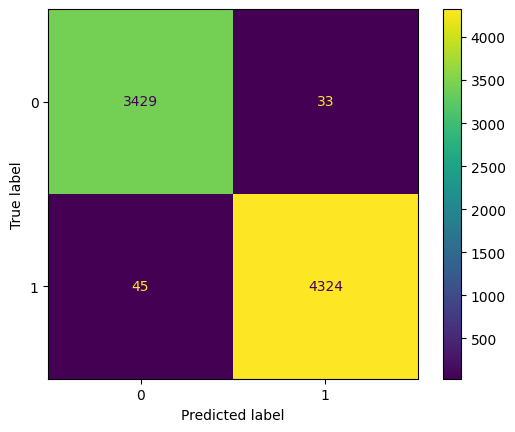

In [ ]:
probs = pipe.predict_proba(X_test)[:,1]
preds = (probs >= 0.5).astype(int)

print("ROC AUC:" , roc_auc_score(y_test,probs))
print(classification_report(y_test,preds, digits= 3))
ConfusionMatrixDisplay.from_predictions(y_test,preds)
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score # Sanity check 1

train_probs = pipe.predict_proba(X_train)[:,1]
test_probs  = pipe.predict_proba(X_test)[:,1]

print("Train AUC:", roc_auc_score(y_train, train_probs))
print("Test  AUC:", roc_auc_score(y_test,  test_probs))

Train AUC: 0.999422072349976
Test  AUC: 0.9993927464639464


In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score

# 1) shuffle TRAIN labels only
y_shuffled = np.random.permutation(y_train)

# 2) fit on shuffled labels
pipe.fit(X_train, y_shuffled)

# 3) evaluate on TEST set vs REAL test labels
shuf_probs_test = pipe.predict_proba(X_test)[:, 1]

print("Shuffled-label test AUC:", roc_auc_score(y_test, shuf_probs_test))

Shuffled-label test AUC: 0.5032427404938872


In [ ]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('tfid',
                 TfidfVectorizer(analyzer='char_wb', max_features=300000,
                                 min_df=2, ngram_range=(3, 5))),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=4000))])

In [ ]:
import joblib, os
os.makedirs("models", exist_ok=True)
joblib.dump(pipe, "models/phishing_risk_model.joblib")

['models/phishing_risk_model.joblib']